# Calibration under shift results walkthrough

I use this notebook to read saved manifests and result tables. It never trains a model. I treat the committed SMIDS and HuSHeM grid as the scientific result. I use the synthetic demo only as an explicit CI fixture.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import yaml

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from experiments.analyze import validate_complete_grid
from experiments.analysis_artifacts import build_main_table, validate_analysis_inputs

def resolved_path(raw, default):
    candidate = Path(raw) if raw else Path(default)
    return (candidate if candidate.is_absolute() else ROOT / candidate).resolve()

ALLOW_DEMO = os.getenv("CALIBRATION_NOTEBOOK_ALLOW_DEMO") == "1"
METRICS_OVERRIDE = os.getenv("CALIBRATION_NOTEBOOK_METRICS")
THRESHOLDS_OVERRIDE = os.getenv("CALIBRATION_NOTEBOOK_THRESHOLDS")
if ALLOW_DEMO and (not METRICS_OVERRIDE or not THRESHOLDS_OVERRIDE):
    raise RuntimeError(
        "demo mode requires CALIBRATION_NOTEBOOK_METRICS and "
        "CALIBRATION_NOTEBOOK_THRESHOLDS"
    )
if not ALLOW_DEMO and (METRICS_OVERRIDE or THRESHOLDS_OVERRIDE):
    raise RuntimeError("fixture path overrides require CALIBRATION_NOTEBOOK_ALLOW_DEMO=1")
RESULTS = resolved_path(os.getenv("CALIBRATION_RESULTS_DIR"), ROOT / "results")
ATTRIBUTION = RESULTS / "attribution"
METRICS_PATH = resolved_path(METRICS_OVERRIDE, RESULTS / "metrics.csv")
THRESHOLDS_PATH = resolved_path(THRESHOLDS_OVERRIDE, RESULTS / "thresholds.csv")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
results_display = RESULTS.relative_to(ROOT) if RESULTS.is_relative_to(ROOT) else RESULTS
print("Repository path .")
print(f"Results path {results_display}")

Repository path .
Results path results


## 1. Prespecified question

I test whether a reliability signal crosses its prespecified threshold before clean accuracy falls by five percentage points. I store the thresholds in a versioned YAML file and keep missing crossings missing.

In [2]:
with (ROOT / "configs" / "analysis_protocol.yaml").open() as handle:
    protocol = yaml.safe_load(handle)
protocol

{'aggregation': {'device_corruptions': ['defocus_blur',
   'motion_blur',
   'gaussian_noise',
   'shot_noise',
   'jpeg',
   'resample',
   'illumination'],
  'severities': [1, 2, 3, 4, 5],
  'required_method_metrics': {'raw_softmax': 'accuracy',
   'temperature': 'ece',
   'vector_scaling': 'ece',
   'aps': 'conformal_coverage',
   'energy': 'mean_ood_score',
   'mahalanobis': 'mean_ood_score',
   'mc_dropout': 'accuracy'},
  'ensemble_method_metrics': {'deep_ensemble': 'accuracy',
   'ensemble_aps': 'conformal_coverage'},
  'order': 'mean within seed across corruptions, then mean and sample standard deviation across seeds',
  'exclude_conditions': ['prior_shift', 'consensus_test']},
 'thresholds': {'accuracy_absolute_drop': 0.05,
  'ece_relative_increase': 2.0,
  'ece_minimum_absolute_increase': 0.02,
  'entropy_relative_increase': 2.0,
  'entropy_minimum_absolute_increase': 0.05,
  'selective_risk_relative_increase': 2.0,
  'selective_risk_minimum_absolute_increase': 0.02,
  'confo

## 2. Data provenance and split contract

I fix training, validation, calibration, and test rows in saved manifests. I fit temperature scaling and APS only on the calibration role. I apply device corruptions only during evaluation.

In [3]:
for dataset in ("smids", "hushem", "kromp"):
    path = ROOT / "data" / "splits" / f"{dataset}.csv"
    if path.exists():
        frame = pd.read_csv(path)
        index = ["fold", "split"] if "fold" in frame else ["split"]
        print(f"\n{dataset} has {len(frame):,} manifest rows")
        display(frame.groupby(index).size().rename("rows").to_frame())
    else:
        print(f"\n{dataset} has no manifest. See results/data_audit.md")


smids has 3,000 manifest rows


,rows
split,
calibration,300
test,300
train,2100
val,300



hushem has 1,080 manifest rows


rows
fold split            
0    calibration    22
     test           44
     train         118
     val            32
1    calibration    22
     test           43
     train         118
     val            33
2    calibration    22
     test           43
     train         118
     val            33
3    calibration    22
     test           43
     train         118
     val            33
4    calibration    22
     test           43
     train         118
     val            33


kromp has no manifest. See results/data_audit.md


## 3. Load completed result rows

I use the committed `results/metrics.csv` as the default scientific output. I use `CALIBRATION_RESULTS_DIR` for an equivalent reproduction directory. I require `CALIBRATION_NOTEBOOK_ALLOW_DEMO=1` and explicit result paths for demo execution.

In [4]:
required = {"dataset", "model", "seed", "fold", "corruption", "severity", "method", "metric", "value"}
if not METRICS_PATH.is_file():
    raise FileNotFoundError(f"result table not found at {METRICS_PATH}")
metrics = pd.read_csv(METRICS_PATH)
missing = required - set(metrics)
if missing:
    raise ValueError(f"metrics file is missing columns {sorted(missing)}")
datasets = set(metrics["dataset"].astype(str))
demo_only = datasets == {"synthetic_demo"}
if demo_only:
    if not ALLOW_DEMO:
        raise ValueError("synthetic demo rows require explicit demo opt-in")
    print("CI-only synthetic fixture. These result cells do not contain scientific output.")
else:
    if ALLOW_DEMO or "synthetic_demo" in datasets:
        raise ValueError("demo mode and scientific results cannot be mixed")
    validate_complete_grid(metrics, protocol)
    print("validated complete prespecified SMIDS/HuSHeM grid")
metrics_display = (
    METRICS_PATH.relative_to(ROOT) if METRICS_PATH.is_relative_to(ROOT) else METRICS_PATH
)
print(f"{len(metrics):,} tidy rows from {metrics_display}")

validated complete prespecified SMIDS/HuSHeM grid
45,540 tidy rows from results/metrics.csv


## 4. Clean baselines

I summarize accuracy and macro-F1 across independent seeds or HuSHeM folds. I use this as an integrity check rather than a shifted-image conclusion.

In [5]:
if metrics.empty:
    print("Skipped because no public-data metrics are available.")
else:
    clean = metrics.query("corruption == 'clean' and method == 'raw_softmax'")
    baseline = (clean[clean.metric.isin(["accuracy", "macro_f1", "ece", "nll"])]
                .groupby(["dataset", "model", "metric"]).value
                .agg(["mean", "std", "count"]))
    display(baseline)

mean       std  count
dataset model              metric                             
hushem  resnet50           accuracy  0.865433  0.078163      5
                           ece       0.132186  0.042489      5
                           macro_f1  0.865413  0.079369      5
                           nll       0.425766  0.185428      5
smids   mobilenet_v3_large accuracy  0.888889  0.016443      3
                           ece       0.039583  0.005918      3
                           macro_f1  0.889577  0.016148      3
                           nll       0.328754  0.034308      3
        resnet50           accuracy  0.896667  0.007071      5
                           ece       0.046832  0.010724      5
                           macro_f1  0.897441  0.006804      5
                           nll       0.308789  0.019844      5
        xception           accuracy  0.887778  0.021688      3
                           ece       0.051577  0.023289      3
                           macro_f1  0.888928  0.020833      3
                           nll       0.311422  0.046248      3

## 5. Primary/prespecified trajectories

I first average corruptions equally within each seed or fold. I then summarize replicates. This gives every registered corruption equal weight.

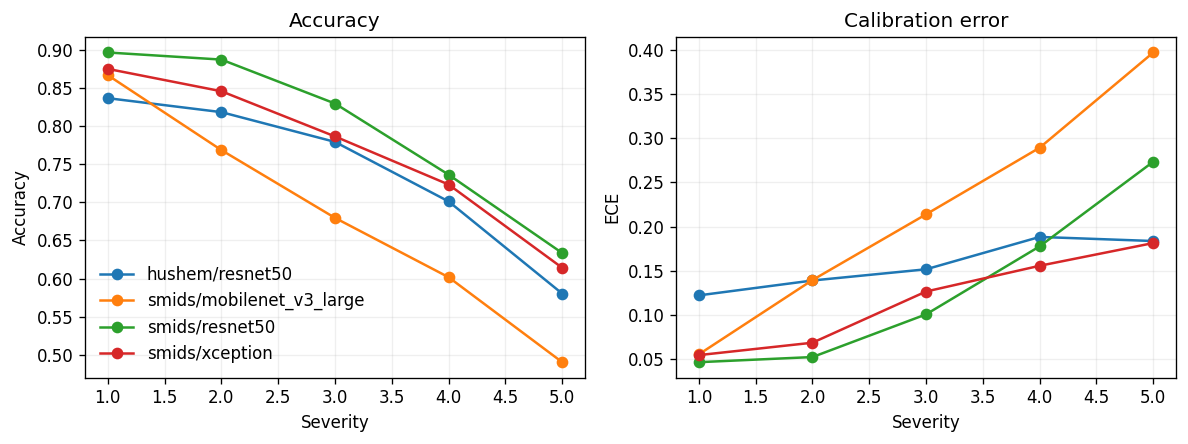

In [6]:
def device_summary(metric_name, method):
    names = set(protocol["aggregation"]["device_corruptions"])
    selected = metrics[(metrics.corruption.isin(names)) &
                       (metrics.metric == metric_name) &
                       (metrics.method == method)].copy()
    if selected.empty:
        return pd.DataFrame()
    within = (selected.groupby(["dataset", "model", "seed", "fold", "severity"], as_index=False, dropna=False)
              .value.mean())
    return (within.groupby(["dataset", "model", "severity"]).value
            .agg(["mean", "std", "count"]).reset_index())

accuracy = device_summary("accuracy", "raw_softmax")
ece = device_summary("ece", "raw_softmax")
if accuracy.empty:
    print("Skipped because no complete public-data grid is available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for keys, group in accuracy.groupby(["dataset", "model"]):
        axes[0].plot(group.severity, group["mean"], marker="o", label="/".join(keys))
    for keys, group in ece.groupby(["dataset", "model"]):
        axes[1].plot(group.severity, group["mean"], marker="o", label="/".join(keys))
    axes[0].set(xlabel="Severity", ylabel="Accuracy", title="Accuracy")
    axes[1].set(xlabel="Severity", ylabel="ECE", title="Calibration error")
    axes[0].legend(frameon=False)
    plt.tight_layout()

## 6. Secondary and exploratory temperature transfer

I fit temperature once on clean calibration logits. I compare raw and temperature-scaled ECE under corruption without refitting on shifted test data.

In [7]:
if metrics.empty:
    print("Skipped because no public-data metrics are available.")
else:
    names = set(protocol["aggregation"]["device_corruptions"])
    comparison = metrics[(metrics.metric == "ece") &
                         (metrics.method.isin(["raw_softmax", "temperature"])) &
                         (metrics.corruption.isin(names))]
    within = (comparison.groupby(
        ["dataset", "model", "method", "seed", "fold", "severity"],
        as_index=False, dropna=False).value.mean())
    display(within.groupby(["dataset", "model", "method", "severity"]).value
            .agg(["mean", "std", "count"]).head(30))

mean       std  count
dataset model              method      severity                           
hushem  resnet50           raw_softmax 1         0.122025  0.017858      5
                                       2         0.138882  0.024344      5
                                       3         0.151581  0.020802      5
                                       4         0.188251  0.019042      5
                                       5         0.183622  0.018593      5
                           temperature 1         0.135267  0.037443      5
                                       2         0.144704  0.036059      5
                                       3         0.169142  0.027333      5
                                       4         0.198196  0.018534      5
                                       5         0.197912  0.030482      5
smids   mobilenet_v3_large raw_softmax 1         0.055189  0.009877      3
                                       2         0.139398  0.065699      3
                                       3         0.213879  0.064999      3
                                       4         0.289379  0.091195      3
                                       5         0.397287  0.136764      3
                           temperature 1         0.049694  0.012777      3
                                       2         0.130180  0.070136      3
                                       3         0.206787  0.065898      3
                                       4         0.281692  0.095780      3
                                       5         0.384232  0.147883      3
        resnet50           raw_softmax 1         0.046313  0.004783      5
                                       2         0.052126  0.002869      5
                                       3         0.100520  0.009816      5
                                       4         0.177599  0.016168      5
                                       5         0.273504  0.019536      5
                           temperature 1         0.040817  0.006196      5
                                       2         0.046517  0.009035      5
                                       3         0.088149  0.013616      5
                                       4         0.161235  0.018003      5
                                       5         0.250861  0.030403      5

## 7. Secondary and exploratory selective prediction and conformal sets

I measure whether 80% retention increases retained accuracy and lowers empirical risk. I report APS coverage and mean set size. The APS nominal guarantee depends on exchangeability and can fail under shift.

In [8]:
if metrics.empty:
    print("Skipped because no public-data metrics are available.")
else:
    names = set(protocol["aggregation"]["device_corruptions"])
    selected = metrics[metrics.metric.isin([
        "risk_at_80_coverage", "conformal_coverage", "conformal_mean_set_size"
    ]) & metrics.corruption.isin(names)]
    within = (selected.groupby(
        ["dataset", "model", "method", "metric", "seed", "fold", "severity"],
        as_index=False, dropna=False).value.mean())
    display(within.groupby(
        ["dataset", "model", "method", "metric", "severity"]
    ).value.agg(["mean", "std", "count"]).head(40))

mean  \
dataset model    method         metric                  severity             
hushem  resnet50 aps            conformal_coverage      1         0.972908   
                                                        2         0.974237   
                                                        3         0.969586   
                                                        4         0.963591   
                                                        5         0.941815   
                                conformal_mean_set_size 1         2.484491   
                                                        2         2.606871   
                                                        3         2.782468   
                                                        4         2.894956   
                                                        5         2.965630   
                 energy         risk_at_80_coverage     1         0.113991   
                                                        2         0.139864   
                                                        3         0.174966   
                                                        4         0.262789   
                                                        5         0.393424   
                 mahalanobis    risk_at_80_coverage     1         0.132721   
                                                        2         0.156893   
                                                        3         0.199184   
                                                        4         0.295170   
                                                        5         0.419342   
                 mc_dropout     risk_at_80_coverage     1         0.102608   
                                                        2         0.120385   
                                                        3         0.170045   
                                                        4         0.247324   
                                                        5         0.373923   
                 raw_softmax    risk_at_80_coverage     1         0.099365   
                                                        2         0.114762   
                                                        3         0.164354   
                                                        4         0.242472   
                                                        5         0.368254   
                 temperature    risk_at_80_coverage     1         0.097732   
                                                        2         0.114762   
                                                        3         0.161905   
                                                        4         0.243288   
                                                        5         0.368254   
                 vector_scaling risk_at_80_coverage     1         0.143039   
                                                        2         0.167392   
                                                        3         0.243787   
                                                        4         0.328798   
                                                        5         0.459229   

                                                                       std  \
dataset model    method         metric                  severity             
hushem  resnet50 aps            conformal_coverage      1         0.018350   
                                                        2         0.015569   
                                                        3         0.008548   
                                                        4         0.013377   
                                                        5         0.010259   
                                conformal_mean_set_size 1         0.197131   
                                                        2         0.181815   
                                                        3         0.108827   
             

## 8. Prespecified threshold result

I use the generated table for the prespecified comparison. I count a reliability measure as earlier only when its threshold crosses at a lower severity than the five-point accuracy-loss threshold. I keep missing crossings missing.

In [9]:
if not THRESHOLDS_PATH.is_file():
    raise FileNotFoundError(f"threshold table not found at {THRESHOLDS_PATH}")
thresholds = pd.read_csv(THRESHOLDS_PATH)
if demo_only:
    print("Synthetic threshold fixture only. I draw no scientific conclusion from it.")
    display(thresholds)
else:
    metrics, thresholds = validate_analysis_inputs(metrics, thresholds, protocol)
    main_table = build_main_table(metrics, thresholds)
    status_counts = main_table["status"].value_counts().to_dict()
    observed = int(status_counts.get("earlier", 0) + status_counts.get("same_or_later", 0))
    earlier = int(status_counts.get("earlier", 0))
    never_crossed = int(status_counts.get("signal_did_not_cross", 0))
    assert (observed, earlier, never_crossed) == (10, 0, 6)
    print(
        "In the primary prespecified result, no reliability signal crossed before the "
        f"accuracy-drop threshold in any of the {observed} comparisons with both "
        f"crossings observed, and {never_crossed} further signals never crossed. "
        "The early-warning hypothesis was not supported at these thresholds on "
        "SMIDS and HuSHeM."
    )
    display(main_table[[
        "analysis_tier", "dataset", "model", "signal_label",
        "signal_crossing_severity", "accuracy_drop_severity", "status"
    ]])

In the primary prespecified result, no reliability signal crossed before the accuracy-drop threshold in any of the 10 comparisons with both crossings observed, and 6 further signals never crossed. The early-warning hypothesis was not supported at these thresholds on SMIDS and HuSHeM.


,analysis_tier,dataset,model,signal_label,signal_crossing_severity,accuracy_drop_severity,status
0,primary/prespecified,smids,resnet50,Raw-softmax ECE,3.0,3.0,same_or_later
1,primary/prespecified,smids,resnet50,Raw-softmax predictive entropy,NaN,3.0,signal_did_not_cross
2,primary/prespecified,smids,resnet50,Raw-softmax risk at 80% coverage,3.0,3.0,same_or_later
3,primary/prespecified,smids,resnet50,APS empirical coverage,NaN,3.0,signal_did_not_cross
4,primary/prespecified,smids,xception,Raw-softmax ECE,3.0,3.0,same_or_later
5,primary/prespecified,smids,xception,Raw-softmax predictive entropy,5.0,3.0,same_or_later
6,primary/prespecified,smids,xception,Raw-softmax risk at 80% coverage,3.0,3.0,same_or_later
7,primary/prespecified,smids,xception,APS empirical coverage,NaN,3.0,signal_did_not_cross
8,primary/prespecified,smids,mobilenet_v3_large,Raw-softmax ECE,2.0,2.0,same_or_later
9,primary/prespecified,smids,mobilenet_v3_large,Raw-softmax predictive entropy,NaN,2.0,signal_did_not_cross


## 9. Secondary and exploratory attribution stability

I compare Grad-CAM maps with fixed clean targets and paired images. I measure Spearman agreement and top-20% saliency IoU. I do not treat images alone as quantitative evidence.

In [10]:
stability_path = ATTRIBUTION / "attribution_stability.csv"
if demo_only:
    print("Skipped for the synthetic fixture. Attribution is not scientific output.")
elif stability_path.exists():
    stability = pd.read_csv(stability_path)
    display(stability.groupby("severity")[["spearman", "top_percent_iou"]]
            .agg(["mean", "std", "count"]))
else:
    raise FileNotFoundError(f"real-checkpoint attribution table not found at {stability_path}")

spearman                     top_percent_iou                
              mean           std count            mean       std count
severity                                                              
0         1.000000  5.132179e-17   600        1.000000  0.000000   600
1         0.998664  4.427660e-03   600        0.987929  0.046225   600
2         0.972965  3.610594e-02   600        0.915978  0.109289   600
3         0.886300  8.458657e-02   600        0.831802  0.137453   600
4         0.853140  1.014197e-01   600        0.806387  0.155823   600
5         0.794051  1.368516e-01   600        0.745054  0.167057   600

## 10. Interpretation discipline

I limit the null result to the prespecified thresholds on these datasets. I do not interpret it as proof that uncertainty methods are useless. Classification degradation, miscalibration, per-sample failure ranking, conformal coverage, input-shift detection, and attribution change address different questions. I treat every analysis outside the primary threshold decision as secondary or exploratory.

## 11. Limitations

I use public proxy datasets without released patient mapping. I exclude Kromp because its public metadata cannot support a patient-grouped split. I use corruptions as sensitivity analyses rather than paired smartphone and clinical captures. I make no clinical-performance or deployment claim.

## 12. References

[Thirumalaraju et al. in Fertility and Sterility](https://doi.org/10.1016/j.fertnstert.2025.08.021) and [Kanakasabapathy et al. in Nature Biomedical Engineering](https://doi.org/10.1038/s41551-021-00733-w) provide the clinical reliability and deployment context. [Guo et al. at ICML](https://proceedings.mlr.press/v70/guo17a.html), [Ovadia et al. at NeurIPS](https://proceedings.neurips.cc/paper_files/paper/2019/hash/8558cb408c1d76621371888657d2eb1d-Abstract.html), and [Angelopoulos and Bates](https://doi.org/10.1561/2200000101) provide the calibration, distribution-shift, and conformal-prediction foundations.

## 13. Next experiment

My next experiment would image each specimen with a reference microscope and low-cost device. I would compare the simulated severity ordering with measured device results while keeping patients grouped and calibration data isolated.